# Gaussian Processes in Higher Dimension

A Gaussian process prior is
$$
f \sim \mathcal{GP}(0, k_\theta(\cdot,\cdot)).
$$
Posterior mean and variance are computed with kernel matrices. We illustrate 2D regression with uncertainty maps.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/gaussian-processes-2d/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/gaussian-processes-2d") if Path("python/gaussian-processes-2d").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Gaussian Processes in Higher Dimension**, with equations and plots designed to expose both the model and the numerical behavior.


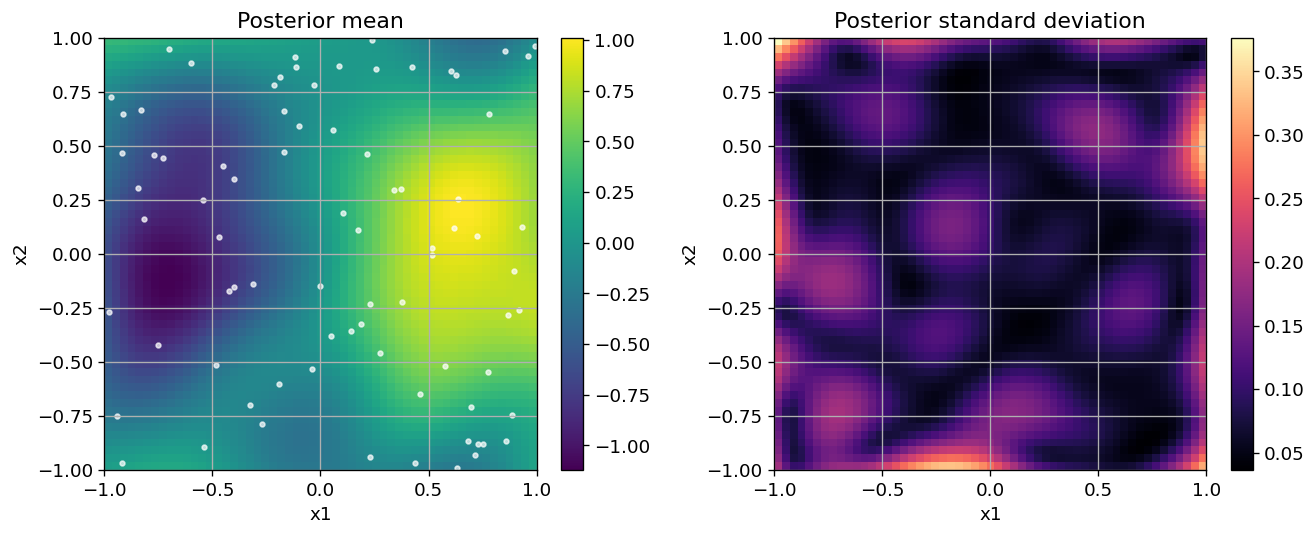

In [2]:
def k_rbf(X1, X2, ell=0.35, sig=1.0):
    d2 = np.sum((X1[:, None, :] - X2[None, :, :])**2, axis=2)
    return sig*np.exp(-0.5*d2/(ell**2))

n_train = 80
Xtr = rng.uniform(-1, 1, size=(n_train, 2))
ftrue = lambda X: np.sin(2.2*X[:, 0]) * np.cos(1.8*X[:, 1])
ytr = ftrue(Xtr) + 0.08*rng.normal(size=n_train)

g = 55
xx = np.linspace(-1, 1, g)
yy = np.linspace(-1, 1, g)
GX, GY = np.meshgrid(xx, yy)
Xte = np.c_[GX.ravel(), GY.ravel()]

K = k_rbf(Xtr, Xtr) + 0.08**2 * np.eye(n_train)
Ks = k_rbf(Xtr, Xte)
Kss = k_rbf(Xte, Xte)
alpha = np.linalg.solve(K, ytr)
m = Ks.T @ alpha
v = np.diag(Kss - Ks.T @ np.linalg.solve(K, Ks))
v = np.maximum(v, 0)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))
im0 = axes[0].imshow(m.reshape(g, g), origin="lower", extent=[-1, 1, -1, 1], cmap="viridis")
axes[0].scatter(Xtr[:, 0], Xtr[:, 1], c="w", s=8, alpha=0.7)
axes[0].set_title("Posterior mean")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.sqrt(v).reshape(g, g), origin="lower", extent=[-1, 1, -1, 1], cmap="magma")
axes[1].set_title("Posterior standard deviation")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- C. E. Rasmussen, C. K. I. Williams, *Gaussian Processes for Machine Learning*, MIT Press, 2006.
- M. L. Stein, *Interpolation of Spatial Data*, Springer, 1999.
- A. G. Wilson, H. Nickisch, "Kernel Interpolation for Scalable Structured Gaussian Processes", ICML, 2015.
